<a href="https://colab.research.google.com/github/Nadaramadan1/Assignment-Week-1/blob/main/coding%20task%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [9]:
img = cv2.imread('/content/evgeni-tcherkasski-c659bBmJpw0-unsplash.jpg')

In [10]:
print("Shape:", img.shape)
print("Data type:", img.dtype)
print("Min pixel:", img.min())
print("Max pixel:", img.max())
print("Mean pixel:", img.mean())

Shape: (427, 640, 3)
Data type: uint8
Min pixel: 0
Max pixel: 255
Mean pixel: 92.17393881733021


In [11]:
print("Top-left 5x5 pixel values:\n", gray[0:5, 0:5])

Top-left 5x5 pixel values:
 [[179 180 112  84 201]
 [206 202 175 138 207]
 [226 223 185 140 195]
 [196 241 219 174 198]
 [144 194 205 180 207]]


In [12]:
# 1. Box blur (averaging)
kernel_blur = np.ones((5, 5), np.float32) / 25
# 3. Sobel edge detection (X direction)
kernel_sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
# 4. Laplacian edge detection
kernel_laplacian = np.array([[0,  1, 0], [1, -4, 1], [0,  1, 0]], dtype=np.float32)
# 5. Sharpening
kernel_sharpen = np.array([[ 0, -1,  0], [-1,  5, -1], [ 0, -1,  0]], dtype=np.float32)

In [13]:
# --- Apply filters --
blurred = cv2.filter2D(gray, -1, kernel_blur)
gaussian = cv2.GaussianBlur(gray, (5, 5), 0)
edge_X = cv2.filter2D(gray, -1, kernel_sobel_x)
laplacian  = cv2.filter2D(gray, -1, kernel_laplacian)
sharpened  = cv2.filter2D(gray, -1, kernel_sharpen)

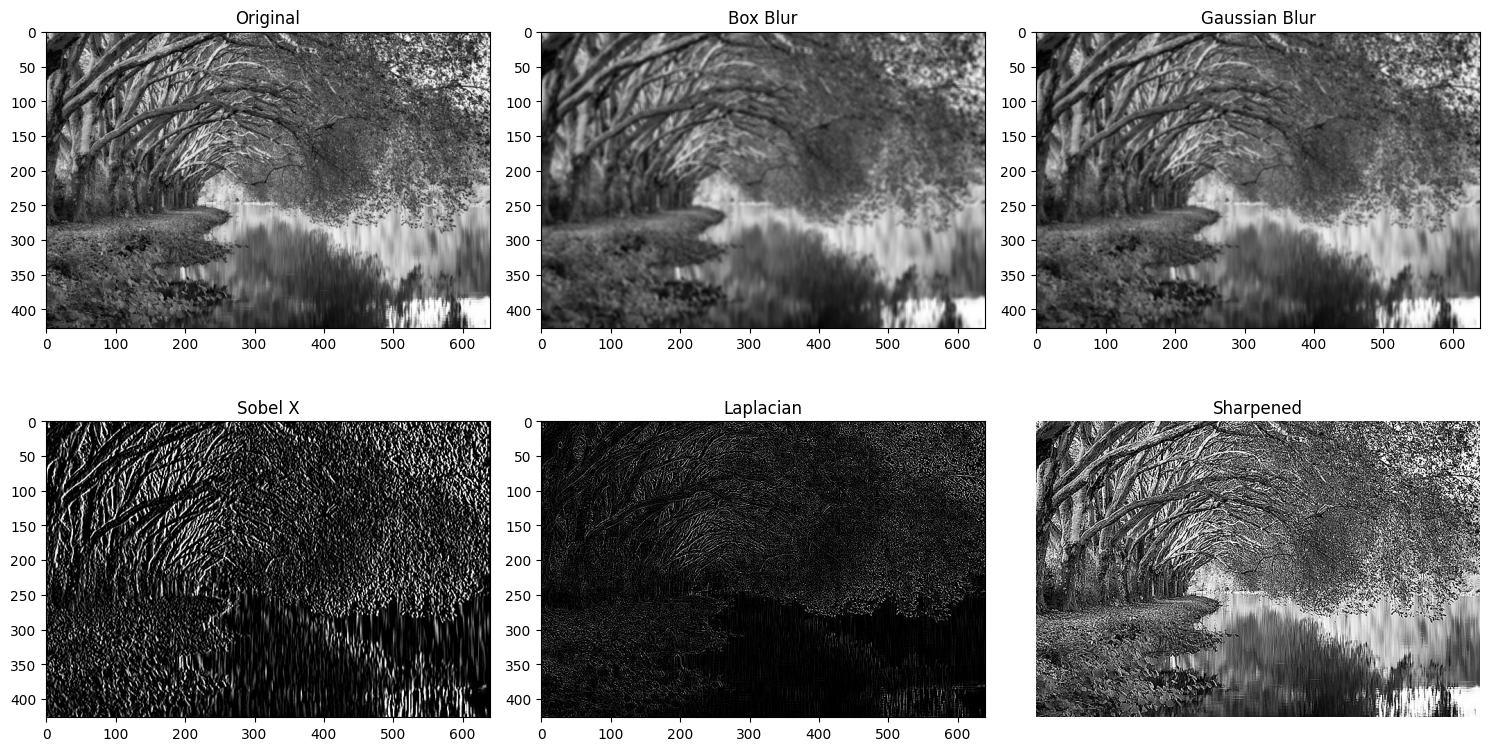

In [14]:
titles  = ['Original', 'Box Blur', 'Gaussian Blur', 'Sobel X', 'Laplacian', 'Sharpened']
images  = [
    gray,
    blurred,
    gaussian,
    np.abs(edge_X).astype(np.uint8),
    np.abs(laplacian).astype(np.uint8),
    sharpened
]

plt.figure(figsize=(15, 8))
for i, (t, im) in enumerate(zip(titles, images)):
    plt.subplot(2, 3, i+1)
    plt.imshow(im, cmap='gray')
    plt.title(t)

plt.axis('off')
plt.tight_layout()
plt.show()